**K-Means**  

Bu uygulamada, K-ortalamalar kümeleme algoritmasının, farklı zorluk seviyelerine sahip sentetik veri kümeleri üzerinde küme içi varyansı minimize ederek etiketlenmiş verileri nasıl gruplandığını göstermektedir. Farklı K değerlerinin seçilmesinin etkilerini incelemiş, performansı dirsek (elbow) yöntemi ve Silhouette skoru kullanarak analiz edilmiş ve ölçeklendirmeye duyarlılık ile küresel olmayan (non- sphrical) verilerde başarısızlık gibi önemli sınırlamaları ortaya konulmuştur.

In [ ]:
#İlk olarak modüllerimizi yükleyelim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

sns.set(style="whitegrid")
np.random.seed(42)

**Basit Sentetik Veri Oluşturma (İyi Ayrışmış Kümeler)**

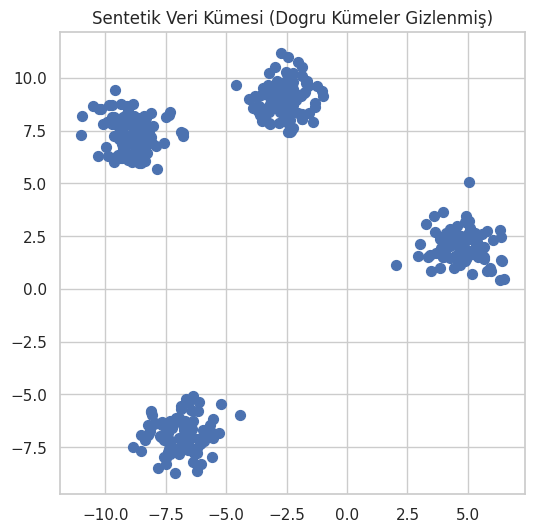

In [ ]:
X, y_true = make_blobs (
    n_samples=400,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=50)
plt.title("Sentetik Veri Kümesi (Dogru Kümeler Gizlenmiş)")
plt.show()

In [ ]:
X

array([[ -9.86267124,   8.72735826],
       [ -4.60499371,   9.67180813],
       [ -9.03492221,   7.10534406],
       [  5.41997462,   1.85552378],
       [  5.09659124,   2.8816222 ],
       [ -3.13580026,   8.75663692],
       [ -2.13060752,   8.956023  ],
       [ -8.42420054,   6.74292786],
       [ -2.43955997,   8.77508025],
       [  5.80079372,   2.74058634],
       [ -8.70163541,   7.17633625],
       [  3.89833446,   1.9255494 ],
       [ -7.33270816,   8.39985895],
       [  4.06763587,   2.51684788],
       [ -7.26971217,  -7.22615614],
       [ -6.84080989,  -7.54486969],
       [ -6.47889344,  -7.66215379],
       [ -2.60171625,   8.77340317],
       [  4.16838703,   2.65285136],
       [ -6.64780731,  -5.21978895],
       [  4.26233334,   2.84433016],
       [ -8.57742134,   6.32263205],
       [ -2.9447038 ,   9.1030242 ],
       [  2.04686496,   1.15365957],
       [ -2.66308639,   9.255524  ],
       [ -9.47070732,   7.7006976 ],
       [ -6.54887927,  -5.37867294],
 

**Veriyi Uygulama**

İlk görselde oluşturduğumuz verinin kaç tane kümesi olduğunu bilmiyoruz. Bu yüzden veriyi kümelere ayırma işlemi yaptık. 4 farklı kümeye ayıracağız

In [ ]:
kmeans= KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

**Grafikleştirme**

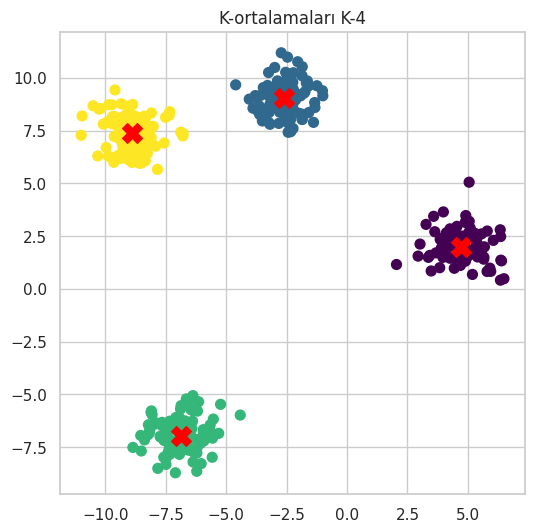

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap="viridis", s=50)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalamaları K-4")
plt.show()

Yanlış K seçersek ne olur?

Durum 1: Çok Az Küme (Yetersiz Küme Sayısı) Seçimi Örneği

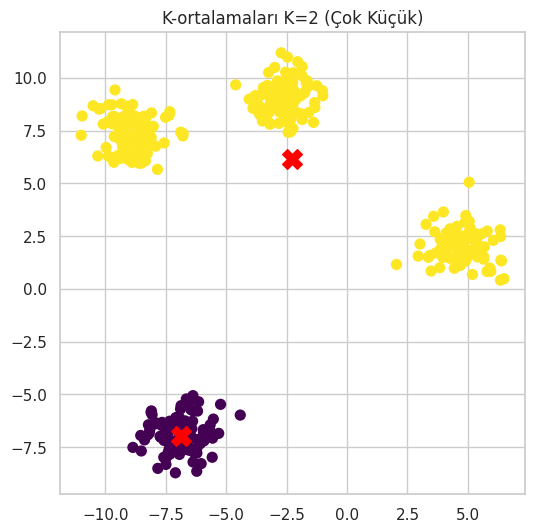

In [ ]:
#2 adet küme seçerek yapalım.

kmeans2= KMeans(n_clusters=2, random_state=42, n_init=10)
clusters2 = kmeans2.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters2, cmap="viridis", s=50)
plt.scatter(kmeans2.cluster_centers_[:,0],
            kmeans2.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalamaları K=2 (Çok Küçük)")
plt.show()



Durum 2: Çok fazla sayıda Küme Seçimi örneği

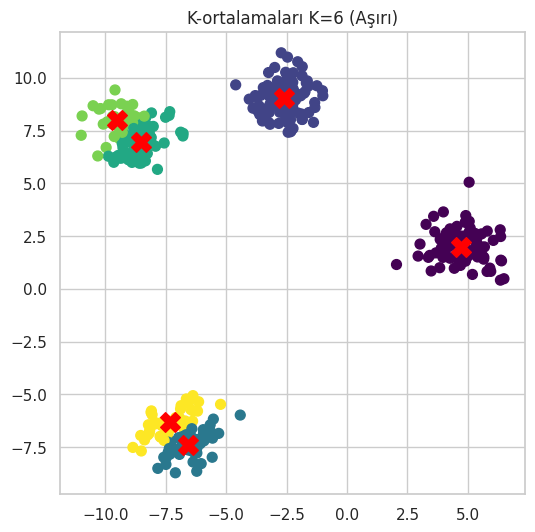

In [ ]:
kmeans6= KMeans(n_clusters=6, random_state=42, n_init=10)
clusters6 = kmeans6.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=clusters6, cmap="viridis", s=50)
plt.scatter(kmeans6.cluster_centers_[:,0],
            kmeans6.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-ortalamaları K=6 (Aşırı)")
plt.show()


**Küme Sayısı Seçimi - Elbow (Dirsek) Yöntemi /Sistematik K Seçimi**

Text(0.5, 1.0, 'Dirsek (Elbow) Yöntemi')

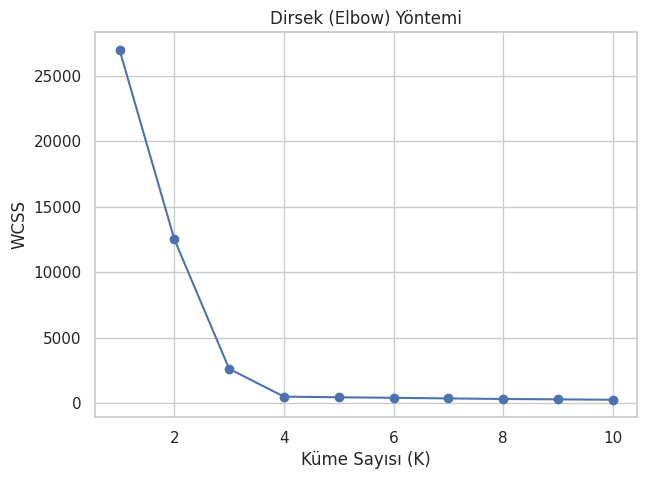

In [ ]:
wcss = [] #Küme içi kareler toplamı

for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X)
  wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("WCSS")
plt.title("Dirsek (Elbow) Yöntemi")





**Silüet Skoru Karşılaştırması**

In [ ]:
for k in range(2,8):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels= km.fit_predict(X)
  score = silhouette_score(X, labels)
  print(f"K={k},Silhouette Score={score:.3f}")






K=2,Silhouette Score=0.604
K=3,Silhouette Score=0.779
K=4,Silhouette Score=0.835
K=5,Silhouette Score=0.724
K=6,Silhouette Score=0.584
K=7,Silhouette Score=0.454


** Problemi Zorlaştırmak (İç İçe Geçmiş/Örtüşen Kümeler)**

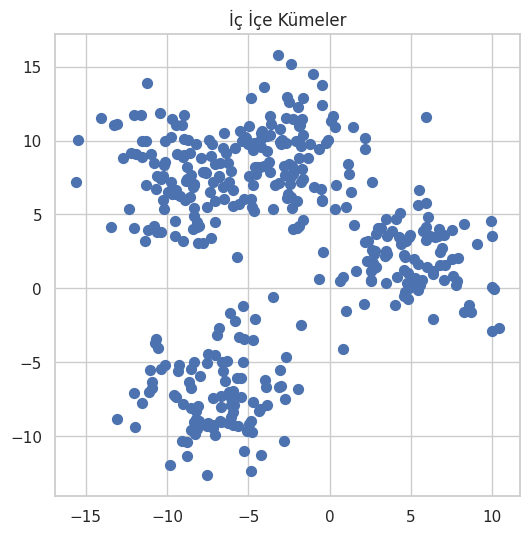

In [ ]:
X_overlap, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=2.5,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_overlap[:,0], X_overlap[:,1], s=50)
plt.title("İç İçe Kümeler")
plt.show()

**K-means Ortalamalarının Uygulanması**

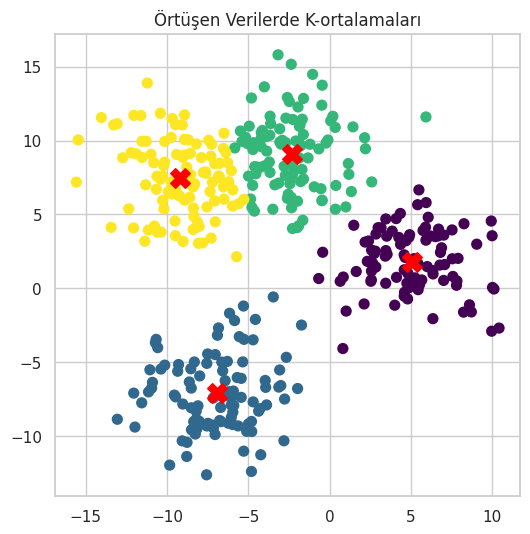

In [ ]:
kmeans_overlap = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_overlap = kmeans_overlap.fit_predict(X_overlap)

plt.figure(figsize=(6,6))
plt.scatter(X_overlap[:,0], X_overlap[:,1], c=labels_overlap, cmap="viridis", s=50)
plt.scatter(kmeans_overlap.cluster_centers_[:,0],
            kmeans_overlap.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Örtüşen Verilerde K-ortalamaları")
plt.show()


**Küresel Olmayan Kümeler (Yanlış Sonuç Verme Durumu)**

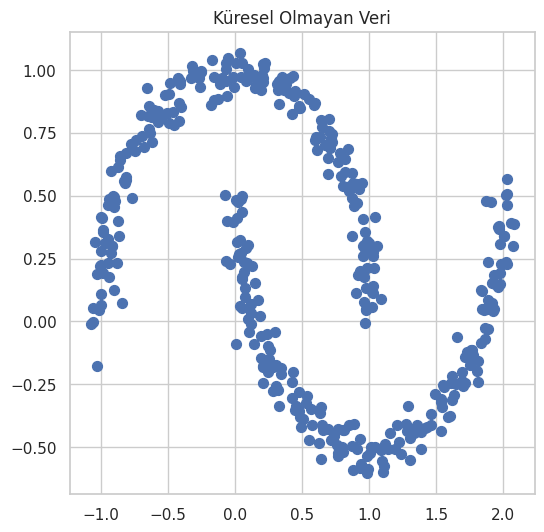

In [ ]:
from sklearn.datasets import make_moons

X_moon, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], s=50)
plt.title("Küresel Olmayan Veri")
plt.show()




Yukarıdaki veriyi K-ortalamaları uygulanınca;

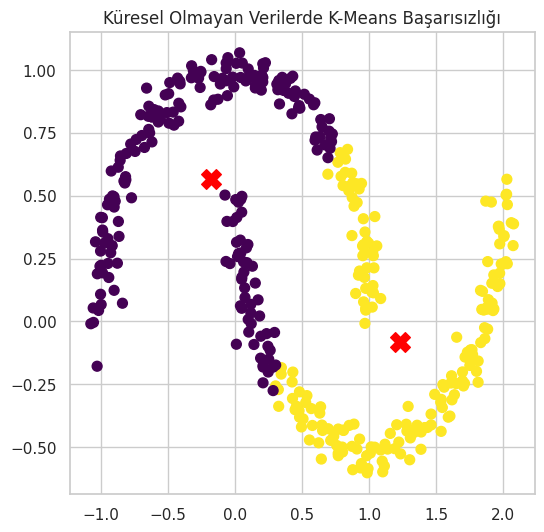

In [ ]:
kmeans_moon = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_moon = kmeans_moon.fit_predict(X_moon)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], c=labels_moon, cmap="viridis", s=50)
plt.scatter(kmeans_moon.cluster_centers_[:,0],
            kmeans_moon.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Küresel Olmayan Verilerde K-Means Başarısızlığı")
plt.show()







**Ölçeklendirmenin önemi**

*Farklı özellik ölçeklerine sahip veri kümesi oluşturma:*

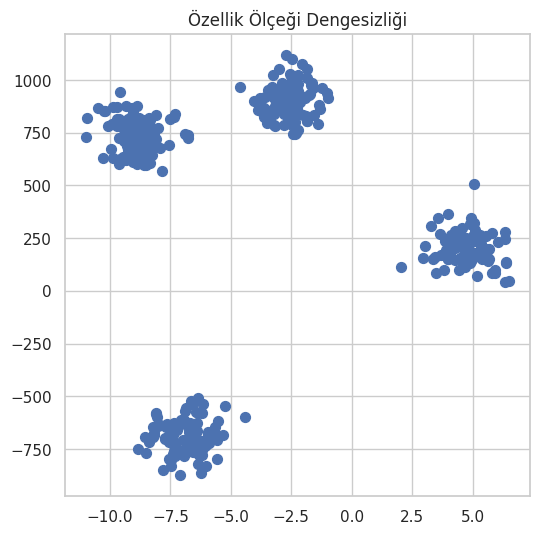

In [ ]:
X_scaled_problem = X.copy()
X_scaled_problem[:,1] = X_scaled_problem[:,1] * 100

plt.figure(figsize=(6,6))
plt.scatter(X_scaled_problem[:,0], X_scaled_problem[:,1], s=50)
plt.title("Özellik Ölçeği Dengesizliği")
plt.show()





Şimdi yukarıdaki ölçeklendirme üzerinde k-ortalama uygulaması yapıyoruz:

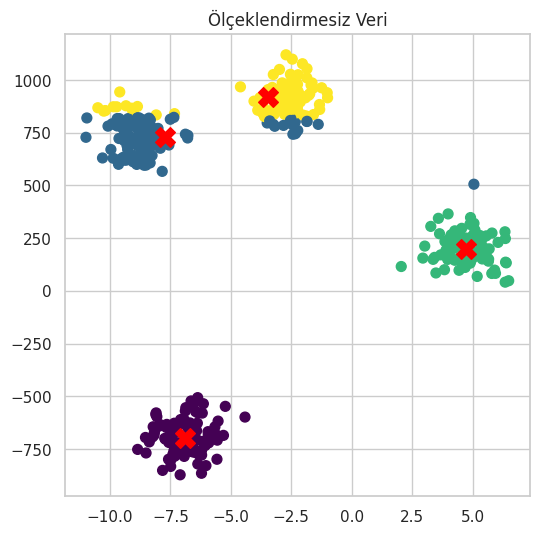

In [ ]:
km_no_scale = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_scale = km_no_scale.fit_predict(X_scaled_problem)


plt.figure(figsize=(6,6))
plt.scatter(X_scaled_problem[:,0], X_scaled_problem[:,1],
            c=labels_no_scale, cmap="viridis", s=50)
plt.scatter(km_no_scale.cluster_centers_[:,0],
            km_no_scale.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Ölçeklendirmesiz Veri")
plt.show()






Yukarıda görüldüğü gibi 4 farklı kümeye ayırmasını seçtik ancak ayıramıyor çünkü küme içi kareleri aynı ölçekte gibi düşünerek topluyor.

Şimdi bunu ölçekleyelim:

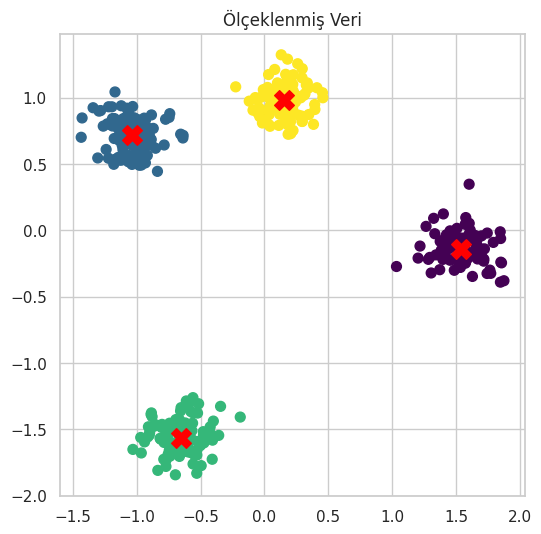

In [ ]:
scaler = StandardScaler()
X_corrected = scaler.fit_transform(X_scaled_problem)

km_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_corrected)

plt.figure(figsize=(6,6))
plt.scatter(X_corrected[:,0], X_corrected[:,1],
            c=labels_scaled, cmap="viridis", s=50)
plt.scatter(km_scaled.cluster_centers_[:,0],
            km_scaled.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("Ölçeklenmiş Veri")
plt.show()






**Sınıflandırma Yapay Sinir Ağları**


**Çok Sınıflandırma - Yapay Sinir Ağları ile**

Bu uygulama; Palmer Penguenleri'nin üç farklı türünü, fiziksel ölçümlerine ve yaşam alanlarına dayanarak sınıflandıran, Yapay Sinir Ağı kullanan bir denetimli makine öğrenmesi iş akışını göstermektedir. "Gerçek dünya" verilerindeki eksik değerlerin işlenmesinden kategorik kodlamaya, özellik ölçeklendirmeden Keras ile model eğitimine kadar tüm  veri yaşam döngüsünü içermektedir. Model, Softmax çıktı katmanını kullanarak olasılık tabanlı tahminler sunar ve sinir ağlarının çok sınıflı karar verme süreçlerini nasıl yönettiğini göstermektedir.


Bu örnekte amacımız özellikleri verilen verinin türünü tahmin etmeye çalışmak. Tür hariç verideki herşey verinin özellikleri, türü ise bizim tahmin edip yapay sinir ağları ile eğiteceğimiz hedef değerimizdir.

Yani; şu aralıkta yaşayan, cinsiyeti şu olan vs vs özelliklere sahip olan penguenin türü budur şeklinde elimizde bir veri seti var. Biz bu bilgilerle modeli eğitiyoruz. Daha sonra verinin türü 'species' dediğimiz kısmı tamamen kapatarak şu özelliklere sahip vs vs olan penguen hangi türdedir. Yapay zeka ile önce bunu eğitim daha sonra veri setinin içerisinde olmayan ancak veri setine benzeyen özellikleri modele tahminletip, modelin başarısını ölçeceğiz.



1- Modüllerin Yüklenmesi

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [5]:
df = sns.load_dataset('penguins')

print("Veri Boyutu:", df.shape)
df.head()

Veri Boyutu: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Veri Hazırlama

1- Eksik verili satırların silinmesi işlemi

In [7]:
df = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [8]:
print("Veri Boyutu:", df.shape)

Veri Boyutu: (333, 7)


Şimdi yapay sinir ağlarıyla sınıflandırmayı yapabilmek için veriyi özelliklerine ve hedeflerine ayırmalıyız.

2- Veriyi özellik ve hedeflerine Ayırma İşlemi

In [9]:
#Verinin Özelliklerinin ve Hedeflerinin Ayrılması
x = df.drop('species', axis=1)
y = df['species']

#Kategorik verileri kodla (Island ve Sex)
#Dizeleri sayılara dönüştürmek için pd.get_dummies kullanıyoruz (one-hot kodlama)
x = pd.get_dummies(x, columns= ['island', 'sex'], drop_first=True)

#Hedef Değişkeni (Türleri) Kodla
#Sinir ağları, hedef değişkenin sayısal veya one-hot kodlanmış olmasını gerektirir

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Orijinal Sınıflar: {le.classes_}")
print(f"Kodlanmış Sınıflar: {np.unique(y_encoded)}")

Orijinal Sınıflar: ['Adelie' 'Chinstrap' 'Gentoo']
Kodlanmış Sınıflar: [0 1 2]


In [14]:
x

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


**Veriyi Bölme ve Ölçekleme**



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Veriyi Bölme - Eğitim/Training (60%) and Testing (40%)
X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.4, random_state=42)

#Veriyi Ölçekleme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train.size

1393

In [18]:
X_test.size

938

**Yapay Sinir Ağını Kurmak**

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    #Giriş Katmanı ve İlk Gizli Katman
    Dense(16, activation= 'relu', input_shape= (X_train.shape[1],)),
    #İkinci Gizli Katman
    Dense(8, activation= 'relu'),
    #Çıkış Katmanı: 3 adet her bir tür için
    Dense(3, activation= 'softmax')
])

#çok sınıflı sınıflandırma için gerekli olan parametreler ile model kurulur
model.compile(optimizer= 'adam',
              loss= 'sparse_categorical_crossentropy',
              metrics= ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

**Modelin Eğitilmesi**

In [22]:
history = model.fit(X_train, y_train, epochs=50, validation_split= 0.3, verbose=1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5036 - loss: 0.9668 - val_accuracy: 0.5000 - val_loss: 0.9628
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5396 - loss: 0.9188 - val_accuracy: 0.5167 - val_loss: 0.9120
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5612 - loss: 0.8736 - val_accuracy: 0.5833 - val_loss: 0.8649
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6259 - loss: 0.8318 - val_accuracy: 0.6667 - val_loss: 0.8187
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7482 - loss: 0.7897 - val_accuracy: 0.7500 - val_loss: 0.7750
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7986 - loss: 0.7496 - val_accuracy: 0.8500 - val_loss: 0.7334
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8417 - loss: 0.7115 - val_accuracy: 0.8667 - val_loss: 0.6940
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8777 - loss: 0.6763 - val_accuracy: 0.9167 - val_loss: 0.6579

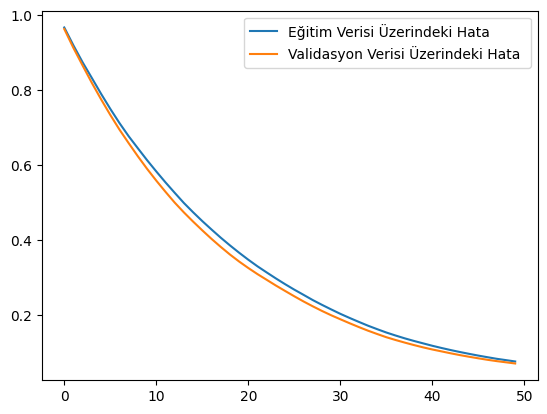

In [23]:
plt.plot(history.history['loss'], label='Eğitim Verisi Üzerindeki Hata')
plt.plot(history.history['val_loss'], label= 'Validasyon Verisi Üzerindeki Hata ')
plt.legend()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9925 - loss: 0.0640 

Test Doğruluğu:  99.25%


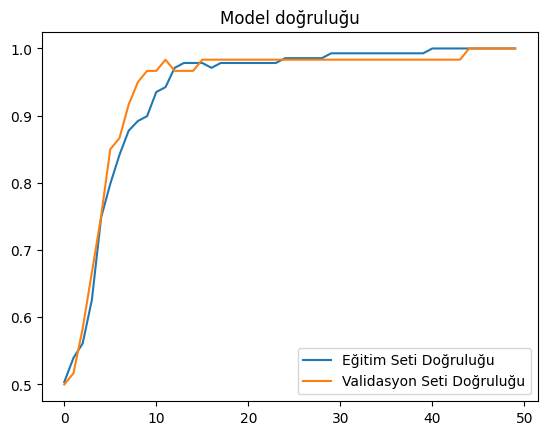

In [24]:
#Test Verisi Üzerinde Değerlendirme
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Doğruluğu: {test_acc * 100: .2f}%")

#Visualization of training progress
plt.plot(history.history['accuracy'], label='Eğitim Seti Doğruluğu')
plt.plot(history.history['val_accuracy'], label = 'Validasyon Seti Doğruluğu')
plt.title('Model doğruluğu')
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Ortalama Doğruluk:  0.9925
F1-Score:  0.9925

Detaylı Kümeleme Raporu: 
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        65
   Chinstrap       1.00      0.96      0.98        27
      Gentoo       1.00      1.00      1.00        42

    accuracy                           0.99       134
   macro avg       0.99      0.99      0.99       134
weighted avg       0.99      0.99      0.99       134



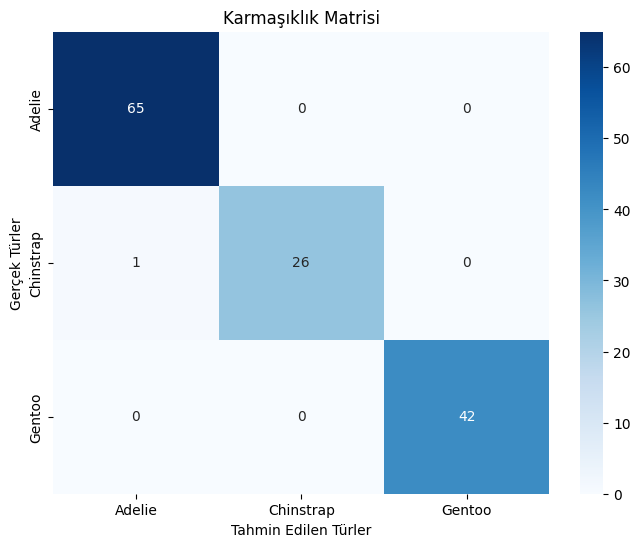

In [25]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns


#1.Test Veri setini modele tahminlet
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


#2. metriklerin hesaplanması
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Ortalama Doğruluk: {accuracy: .4f}")
print(f"F1-Score: {f1: .4f}")
print("\nDetaylı Kümeleme Raporu: ")
print(classification_report(y_test, y_pred, target_names=le.classes_))


#3.Karmaşıklık Matrisi
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Tahmin Edilen Türler')
plt.ylabel('Gerçek Türler')
plt.title('Karmaşıklık Matrisi')
plt.show()





Model hazır olduktan sonra nasıl bir veri noktasını tahminletiriz?

In [27]:
#1. Test verisinden bir satır seçilir
single_sample = X_test[0:1]
single_sample

array([[-0.91642451, -0.20021488, -1.69342818, -1.19778865,  1.2858201 ,
        -0.37032804, -1.03581691]])

In [28]:
#2. Olasılık dağılımı tahmin ettirilir

prediction_probs = model.predict(single_sample)
prediction_probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[0.88001037, 0.11800032, 0.00198933]], dtype=float32)

In [31]:
#3. Olasılığı en yüksek indeksli tür bulunur

predicted_class_index = np.argmax(prediction_probs)
predicted_class_index

np.int64(0)

In [32]:
# 4. bulunan indeks ters transformasyonla gerçek tür adı tahminlenir

predicted_species = le.inverse_transform([predicted_class_index])
predicted_species

array(['Adelie'], dtype=object)

In [34]:
print(f"Her sınıf için olasılıklar: {prediction_probs}")
print(f"Tahminlenen Tür: {predicted_species[0]}")
print(f"Gerçek tür: {le.inverse_transform([y_test[0]])[0]}")

Her sınıf için olasılıklar: [[0.88001037 0.11800032 0.00198933]]
Tahminlenen Tür: Adelie
Gerçek tür: Adelie
